<a href="https://colab.research.google.com/github/ngtan369/Randomized-SVD-in-compress-Data/blob/main/svd_compressData.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Đề tài 10 — Randomized SVD và ứng dụng nén dữ liệu

**Nhóm L05 — Đại số tuyến tính (CSLT 242) — GVHD: Nguyễn Hữu Hiệp**

Notebook này chạy *end-to-end* toàn bộ thí nghiệm của báo cáo:

1. **Sanity check** — Randomized SVD tự viết, so sánh độ chính xác với `numpy.linalg.svd`.
2. **Thí nghiệm A — Ma trận DÀY (ảnh xám 512×512):** Randomized SVD nén thật.
3. **Thí nghiệm B — Ma trận THƯA (MovieLens-like):** SVD không nén được khi mật độ quá thấp.
4. **Benchmark:** so sánh thời gian Custom RSVD vs `sklearn` vs full SVD.

## 0. Setup — clone repo helper từ GitHub

In [13]:
import os, sys, subprocess

REPO_URL = "https://github.com/ngtan369/Randomized-SVD-in-compress-Data.git"
REPO_DIR = "Randomized-SVD-in-compress-Data"

if not os.path.exists(REPO_DIR):
    print(f"Cloning {REPO_URL} ...")
    subprocess.run(["git", "clone", "--depth", "1", REPO_URL, REPO_DIR], check=True)
else:
    print(f"{REPO_DIR} already exists -- pulling latest.")
    subprocess.run(["git", "-C", REPO_DIR, "pull", "--ff-only"], check=False)

subprocess.run([sys.executable, "-m", "pip", "install", "-q", "scikit-image"], check=True)

PROJECT_ROOT = os.path.abspath(REPO_DIR)
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)
os.chdir(PROJECT_ROOT)
print("\nWorking dir:", os.getcwd())
print("Top-level :", sorted(p for p in os.listdir() if not p.startswith('.'))[:12])

Cloning https://github.com/ngtan369/Randomized-SVD-in-compress-Data.git ...

Working dir: /content/Randomized-SVD-in-compress-Data/Randomized-SVD-in-compress-Data
Top-level : ['README.md', 'REQUIREMENTS_CHECKLIST.md', 'report', 'requirements.txt', 'results', 'run_all.sh', 'src', 'svd_compressData.ipynb']


In [14]:
import json, time
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Image, display, Markdown

from src.rsvd import randomized_svd  # cài đặt tự viết của nhóm

print("NumPy             :", np.__version__)
print("Custom RSVD module:", randomized_svd.__module__)

NumPy             : 2.0.2
Custom RSVD module: src.rsvd


## 1. Sanity check — Custom RSVD vs `numpy.linalg.svd`

Chạy thuật toán tự viết trên ma trận 200×100 với hạng đích $k=20$, so sánh sai số Frobenius với xấp xỉ hạng-$k$ tối ưu từ SVD đầy đủ của NumPy.

**Lý thuyết kiểm chứng:**
- Định lý Eckart–Young: sai số tối ưu $= \sqrt{\sum_{i>k}\sigma_i^2}$.
- Halko–Martinsson–Tropp: Randomized SVD chỉ lệch một hằng số nhỏ so với optimum.

In [15]:
rng = np.random.default_rng(0)
A = rng.standard_normal(size=(200, 100))
k = 20

# (a) Xấp xỉ hạng-k tối ưu từ full SVD (numpy)
Uf, sf, Vtf = np.linalg.svd(A, full_matrices=False)
A_full_k = (Uf[:, :k] * sf[:k]) @ Vtf[:k, :]
err_full = np.linalg.norm(A - A_full_k, ord="fro")

# (b) Custom Randomized SVD
Ur, sr, Vtr = randomized_svd(A, k=k, p=10, q=2, random_state=0)
A_rsvd_k = (Ur * sr) @ Vtr
err_rsvd = np.linalg.norm(A - A_rsvd_k, ord="fro")

print(f"Full SVD  optimal rank-{k} ||A-A_k||_F = {err_full:.6f}")
print(f"Custom RSVD       rank-{k} ||A-A_k||_F = {err_rsvd:.6f}")
print(f"Relative gap = {(err_rsvd - err_full) / err_full * 100:.4f}%\n")
print("Top-10 singular values agreement:")
for i in range(10):
    print(f"  i={i:2d}  numpy={sf[i]:.6f}  rsvd={sr[i]:.6f}  diff={abs(sf[i]-sr[i]):.2e}")

Full SVD  optimal rank-20 ||A-A_k||_F = 106.967851
Custom RSVD       rank-20 ||A-A_k||_F = 108.201704
Relative gap = 1.1535%

Top-10 singular values agreement:
  i= 0  numpy=23.299341  rsvd=23.193953  diff=1.05e-01
  i= 1  numpy=22.800322  rsvd=22.447693  diff=3.53e-01
  i= 2  numpy=22.382840  rsvd=22.169800  diff=2.13e-01
  i= 3  numpy=22.183661  rsvd=22.024234  diff=1.59e-01
  i= 4  numpy=21.548818  rsvd=21.301738  diff=2.47e-01
  i= 5  numpy=21.325465  rsvd=21.154589  diff=1.71e-01
  i= 6  numpy=21.255353  rsvd=21.103509  diff=1.52e-01
  i= 7  numpy=20.729572  rsvd=20.435045  diff=2.95e-01
  i= 8  numpy=20.545104  rsvd=20.342355  diff=2.03e-01
  i= 9  numpy=20.381067  rsvd=20.214098  diff=1.67e-01


## 2. Thí nghiệm A — Nén ảnh xám 512×512 (ma trận DÀY)

Dùng ảnh `skimage.data.camera` ($A \in \mathbb{R}^{512\times 512}$, mọi phần tử khác 0).

Áp dụng Randomized SVD với $k \in \{5, 10, 20, 50, 100, 200\}$, so sánh trực quan và tính tỉ lệ nén.

**Break-even kỳ vọng:** $k_{be} = \dfrac{mn}{m+n+1} = \dfrac{512 \cdot 512}{1025} \approx 256$ — mọi $k < 256$ đều nén được.

In [16]:
t0 = time.time()
ret = subprocess.run([sys.executable, "src/experiment_image.py"], capture_output=True, text=True)
print(ret.stdout[-1500:])
if ret.returncode != 0:
    print("STDERR:\n", ret.stderr[-1500:])
print(f"\nElapsed: {time.time() - t0:.1f}s")

[image_experiment] source = skimage.data.camera
[image_experiment] rsvd source = custom
[image_experiment] shape = 512x512 (total=262144)
[image_experiment] ||A||_F = 76080.2273
[image_experiment] break-even k = 255.75
[image_experiment] selected k (eta=0.90/0.95/0.99) = {'0.90': 2, '0.95': 3, '0.99': 21}
[image_experiment] per-k results:
  k=   5  rel_err=0.1720  ratio=51.150  energy=0.9704  time=0.010s
  k=  10  rel_err=0.1350  ratio=25.575  energy=0.9818  time=0.010s
  k=  20  rel_err=0.1013  ratio=12.788  energy=0.9897  time=0.014s
  k=  50  rel_err=0.0640  ratio=5.115  energy=0.9959  time=0.027s
  k= 100  rel_err=0.0398  ratio=2.558  energy=0.9984  time=0.057s
  k= 200  rel_err=0.0180  ratio=1.279  energy=0.9997  time=0.471s
  k= 256  rel_err=0.0109  ratio=0.999  energy=0.9999  time=1.022s
[image_experiment] best compression ratio = 51.150 at k=5
[image_experiment] JSON written to /content/Randomized-SVD-in-compress-Data/Randomized-SVD-in-compress-Data/results/image_experiment.jso

**So sánh ảnh tái dựng ở các giá trị k khác nhau**

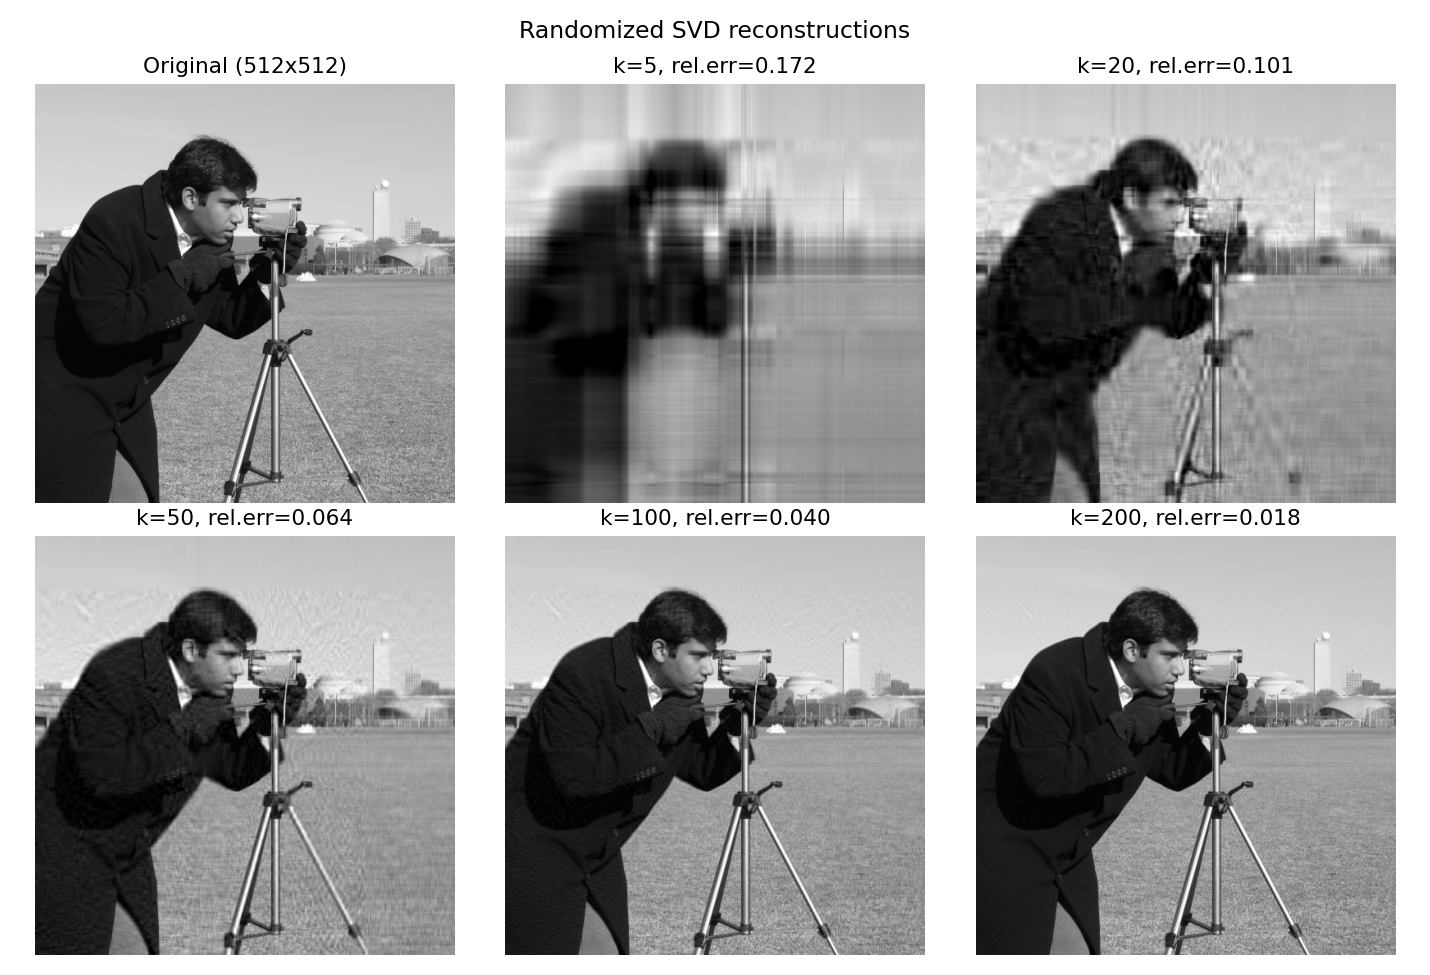

**Phổ kỳ dị của ảnh (suy giảm nhanh)**

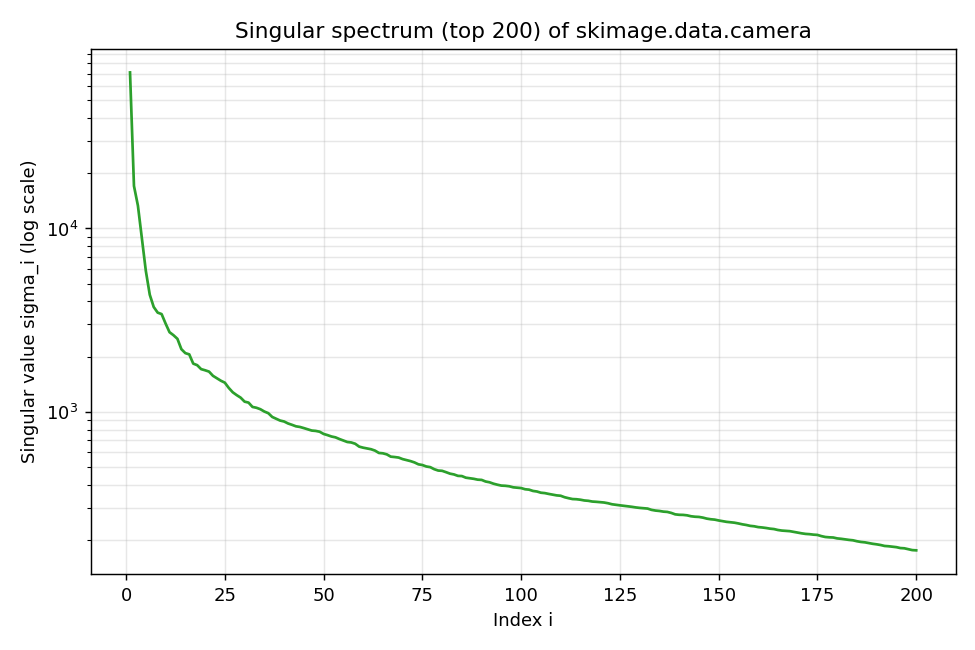

**Năng lượng tích lũy theo k**

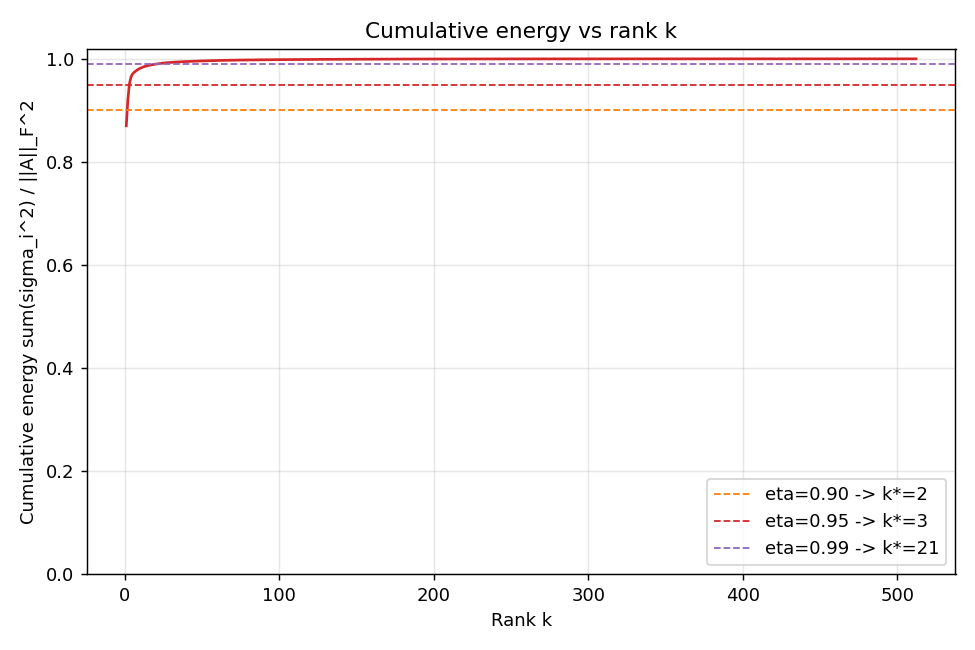

**Tỉ lệ nén theo k (break-even tại 1.0)**

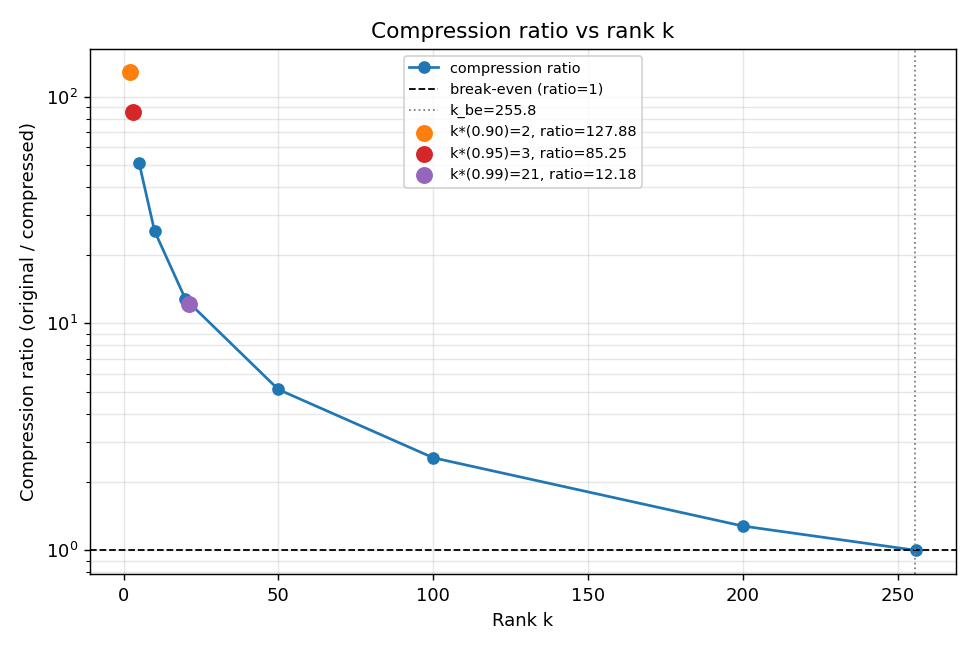

In [17]:
for fname, caption in [
    ("image_reconstruction_grid.png", "So sánh ảnh tái dựng ở các giá trị k khác nhau"),
    ("image_singular_spectrum.png",   "Phổ kỳ dị của ảnh (suy giảm nhanh)"),
    ("image_energy_vs_k.png",         "Năng lượng tích lũy theo k"),
    ("image_compression_curve.png",   "Tỉ lệ nén theo k (break-even tại 1.0)"),
]:
    path = f"report/images/results/{fname}"
    if os.path.exists(path):
        display(Markdown(f"**{caption}**"))
        display(Image(path))
    else:
        print(f"[missing] {path}")

In [18]:
with open("results/image_experiment.json") as fh:
    img_res = json.load(fh)

m_img, n_img = img_res["image_shape"]
frob_norm    = img_res["frobenius_norm"]
print(f"Ảnh   : {m_img}x{n_img} = {m_img*n_img} pixels")
print(f"||A||_F   = {frob_norm:.2f}")
print(f"||A||_F^2 = {frob_norm**2:.4e}")
print(f"Break-even k_be = mn/(m+n+1) = {img_res['break_even_k']:.1f}")
print("\n{:>5}  {:>11}  {:>11}  {:>11}  {:>9}".format("k", "comp ratio", "rel err", "energy", "time(s)"))
for row in img_res["results"]:
    print(f"{row['k']:>5}  {row['compression_ratio']:>10.2f}x  {row['relative_error']:>10.3%}  {row['energy_retention']:>10.3%}  {row['time_seconds']:>9.3f}")

Ảnh   : 512x512 = 262144 pixels
||A||_F   = 76080.23
||A||_F^2 = 5.7882e+09
Break-even k_be = mn/(m+n+1) = 255.8

    k   comp ratio      rel err       energy    time(s)
    5       51.15x     17.202%     97.041%      0.010
   10       25.58x     13.504%     98.176%      0.010
   20       12.79x     10.132%     98.973%      0.014
   50        5.12x      6.397%     99.591%      0.027
  100        2.56x      3.985%     99.841%      0.057
  200        1.28x      1.802%     99.968%      0.471
  256        1.00x      1.089%     99.988%      1.022


## 3. Thí nghiệm B — Ma trận thưa MovieLens-like

Ma trận synthetic 5000 × 2000 mô phỏng MovieLens (mật độ 1%, $\mathrm{nnz} \approx 10^5$), sinh từ mô hình latent hạng-10 + popularity bias.

**Lý do dùng synthetic thay vì download MovieLens 25M (~250 MB):** Colab session có giới hạn bộ nhớ, và mục tiêu là minh hoạ *điều kiện break-even* — synthetic vẫn cho đúng cấu trúc cần kiểm chứng.

**Break-even kỳ vọng:** $k_{be} = \mathrm{nnz}/(m+n+1) \approx 14$ — rất nhỏ ⇒ SVD **không** nén được ma trận thưa.

In [19]:
t0 = time.time()
ret = subprocess.run([sys.executable, "src/experiment_movielens.py"], capture_output=True, text=True)
print(ret.stdout[-2000:])
if ret.returncode != 0:
    print("STDERR:\n", ret.stderr[-1500:])
print(f"\nElapsed: {time.time() - t0:.1f}s")

[1/6] Loading MovieLens rating matrix (real first, synthetic fallback)...
      Trying real MovieLens 25M (GroupLens / Kaggle mirror)...
      Download FAILED: <urlopen error timed out>
      Real data unavailable — falling back to synthetic.
      Building synthetic 5000x2000 sparse matrix...
      shape = (5000, 2000), nnz = 100000, density = 1.0000%
[2/6] Computing exact Frobenius energy from A...
      ||A||_F^2 = 1.241653e+06, ||A||_F = 1.114295e+03
[3/6] Running randomized SVD (backend=custom) at k_max=1500...
      done in 19.19 s; s.shape = (1500,)
[4/6] Locating k* for each target energy ratio...
      eta=0.90: k* = 905
      eta=0.95: k* = 1171
      eta=0.99: not reached at k_max=1500 (max ratio = 0.9817)
[5/6] Storage analysis...
      original CSR storage ~= 1,600,000 B (nnz*16)
      break-even k_be = nnz / (m+n+1) = 14.28
      eta=0.90: k*=905, err=3.5220e+02, compressed=50,687,240 B (31.68x original)
      eta=0.95: k*=1171, err=2.4895e+02, compressed=65,585,368 B (40

**Phổ kỳ dị (suy giảm chậm — đặc trưng ma trận thưa)**

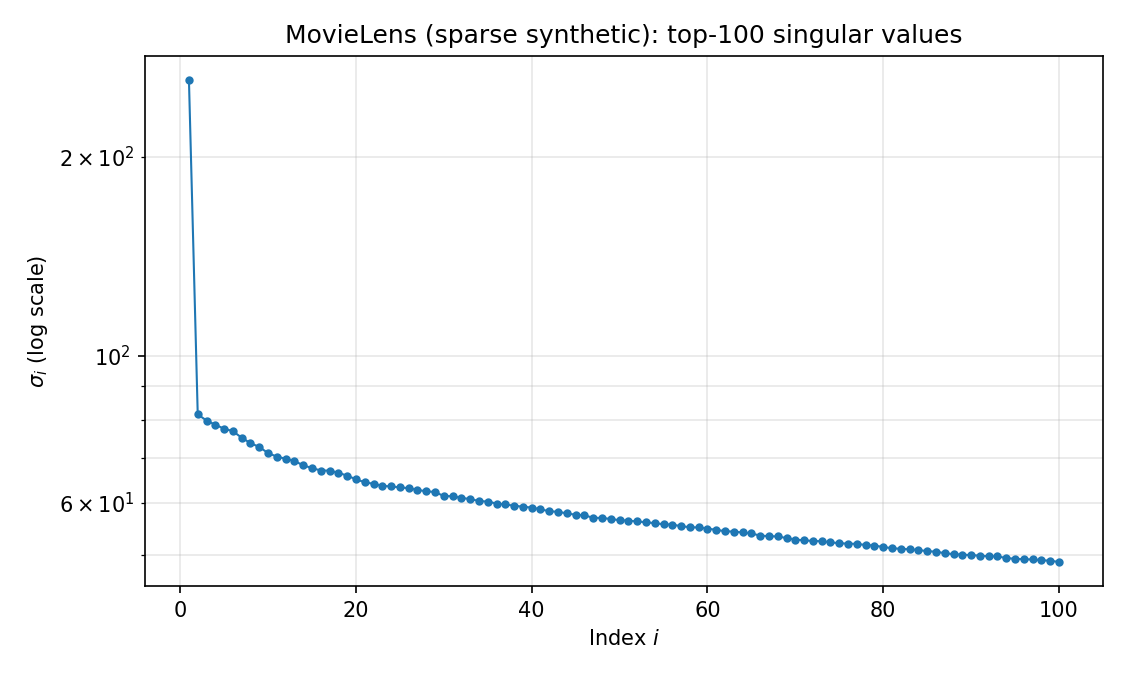

**Năng lượng tích lũy: cần k rất lớn để đạt 90/95%**

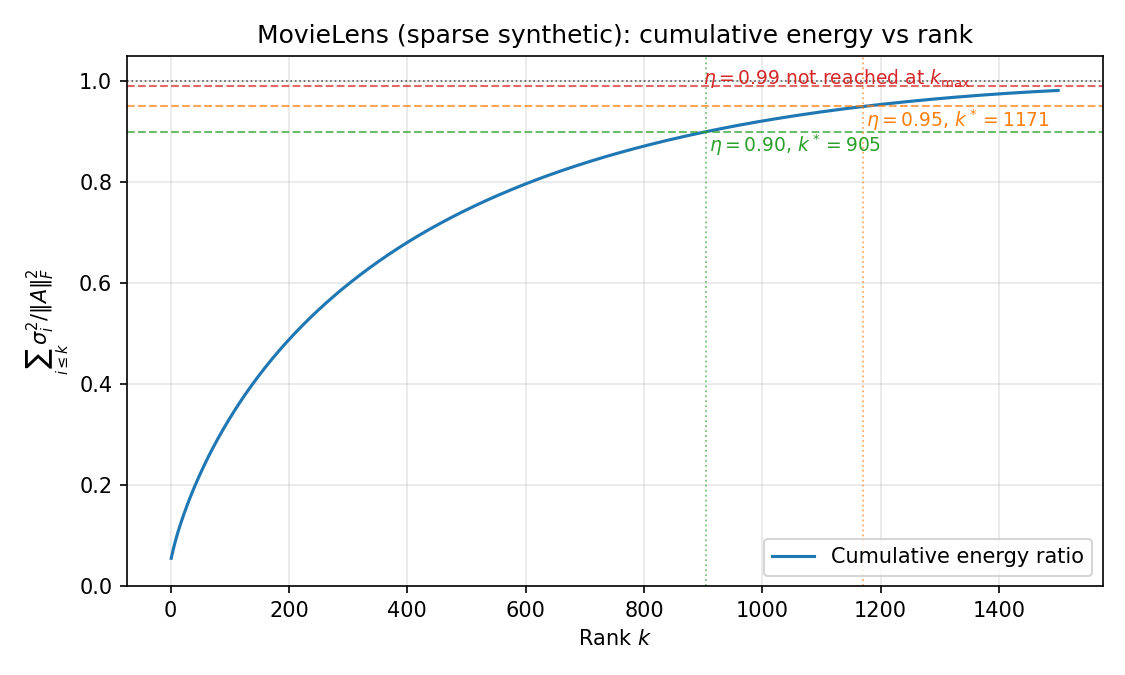

**Sai số Frobenius giảm chậm theo k**

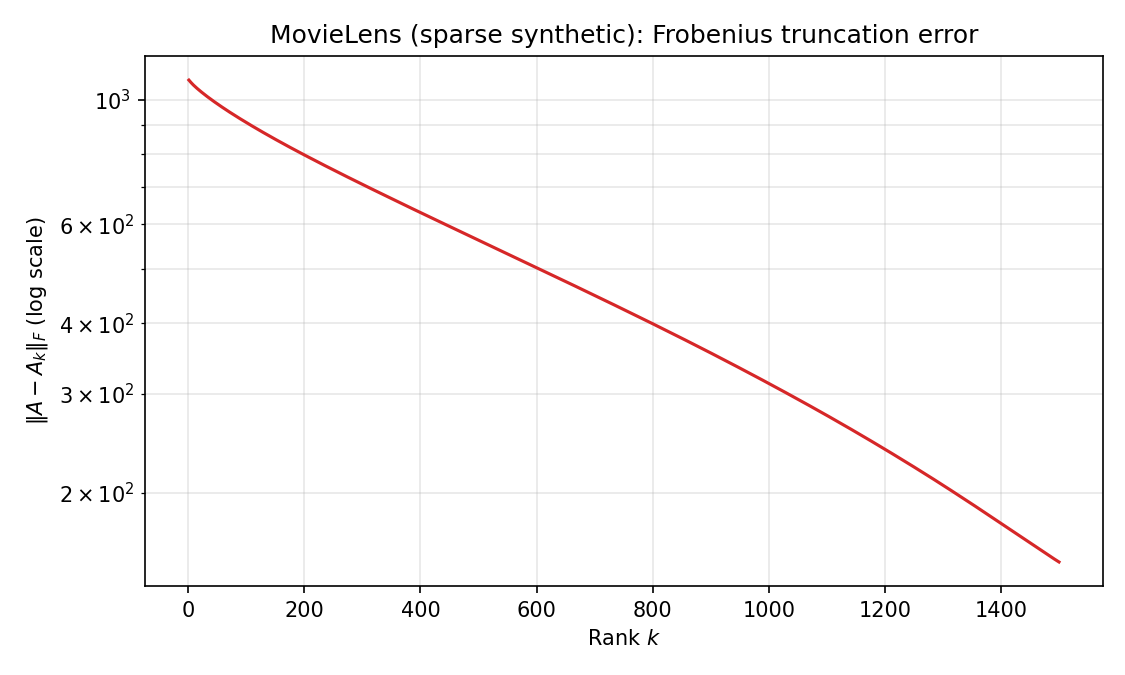

In [20]:
for fname, caption in [
    ("movielens_spectrum.png", "Phổ kỳ dị (suy giảm chậm — đặc trưng ma trận thưa)"),
    ("movielens_energy.png",   "Năng lượng tích lũy: cần k rất lớn để đạt 90/95%"),
    ("movielens_error.png",    "Sai số Frobenius giảm chậm theo k"),
]:
    path = f"report/images/results/{fname}"
    if os.path.exists(path):
        display(Markdown(f"**{caption}**"))
        display(Image(path))

In [21]:
with open("results/movielens_experiment.json") as fh:
    ml_res = json.load(fh)

m, n = ml_res["shape"]
nnz  = ml_res["nnz"]
print(f"Ma trận thưa: {m}x{n}, nnz={nnz} (density={ml_res['density']:.2%})")
print(f"||A||_F^2 (tính trực tiếp từ A.power(2).sum()) = {ml_res['total_energy']:.4e}")
print(f"Break-even k_be = nnz/(m+n+1) = {ml_res['break_even_k']:.2f}\n")

print("k* theo tỉ lệ năng lượng η:")
for eta, k_star in ml_res["selected_k"].items():
    if k_star is None:
        print(f"  η={eta}: chưa đạt với k_max={ml_res['k_max']}")
    else:
        ratio = (k_star * (m+n+1)) / nnz
        print(f"  η={eta}: k*={k_star}  ⇒ biểu diễn nén LỚN GẤP {ratio:.1f}x ma trận CSR gốc")
print(f"\nKết luận: {ml_res['conclusion']}")

Ma trận thưa: 5000x2000, nnz=100000 (density=1.00%)
||A||_F^2 (tính trực tiếp từ A.power(2).sum()) = 1.2417e+06
Break-even k_be = nnz/(m+n+1) = 14.28

k* theo tỉ lệ năng lượng η:
  η=0.90: k*=905  ⇒ biểu diễn nén LỚN GẤP 63.4x ma trận CSR gốc
  η=0.95: k*=1171  ⇒ biểu diễn nén LỚN GẤP 82.0x ma trận CSR gốc
  η=0.99: chưa đạt với k_max=1500

Kết luận: Compression fails: every k* >= break-even k_be ~= 14.3, so a dense rank-k factorization needs more storage than the original CSR matrix.


## 4. Benchmark — Custom RSVD vs `sklearn` vs full SVD

So sánh thời gian chạy trên ma trận dày Gauss ngẫu nhiên kích thước $n \in \{200, 500, 1000, 2000\}$, hạng đích $k=50$.

**Kỳ vọng từ lý thuyết:**
- Custom RSVD ≈ sklearn RSVD (cùng thuật toán HMT, độ phức tạp $\mathcal{O}((mn + (m+n)\ell)\ell)$).
- Cả hai nhanh hơn full SVD ($\mathcal{O}(mn\min(m,n))$) theo lũy thừa của $n$ khi $k \ll \min(m,n)$.

In [22]:
t0 = time.time()
ret = subprocess.run([sys.executable, "src/benchmark.py"], capture_output=True, text=True)
print(ret.stdout[-2000:])
if ret.returncode != 0:
    print("STDERR:\n", ret.stderr[-1500:])
print(f"\nElapsed: {time.time() - t0:.1f}s")


=== Ma trận 200 x 200 ===
  ||A||_F = 3.2026
  [   custom_rsvd] time=  0.0250s  ||A-A_k||_F=2.4655e-01  rel=7.6985e-02  (runs=3)
  [  sklearn_rsvd] time=  0.0225s  ||A-A_k||_F=2.4650e-01  rel=7.6970e-02  (runs=3)
  [numpy_full_svd] time=  0.0219s  ||A-A_k||_F=2.4642e-01  rel=7.6945e-02  (runs=3)

=== Ma trận 500 x 500 ===
  ||A||_F = 3.2026
  [   custom_rsvd] time=  0.0459s  ||A-A_k||_F=2.4656e-01  rel=7.6988e-02  (runs=3)
  [  sklearn_rsvd] time=  0.0390s  ||A-A_k||_F=2.4652e-01  rel=7.6976e-02  (runs=3)
  [numpy_full_svd] time=  0.1174s  ||A-A_k||_F=2.4642e-01  rel=7.6945e-02  (runs=3)

=== Ma trận 1000 x 1000 ===
  ||A||_F = 3.2026
  [   custom_rsvd] time=  0.0606s  ||A-A_k||_F=2.4648e-01  rel=7.6964e-02  (runs=3)
  [  sklearn_rsvd] time=  0.0717s  ||A-A_k||_F=2.4650e-01  rel=7.6969e-02  (runs=3)
  [numpy_full_svd] time=  0.8470s  ||A-A_k||_F=2.4642e-01  rel=7.6946e-02  (runs=3)

=== Ma trận 2000 x 2000 ===
  ||A||_F = 3.2026
  [   custom_rsvd] time=  0.1983s  ||A-A_k||_F=2.4652e-0

**Thời gian chạy theo kích thước ma trận**

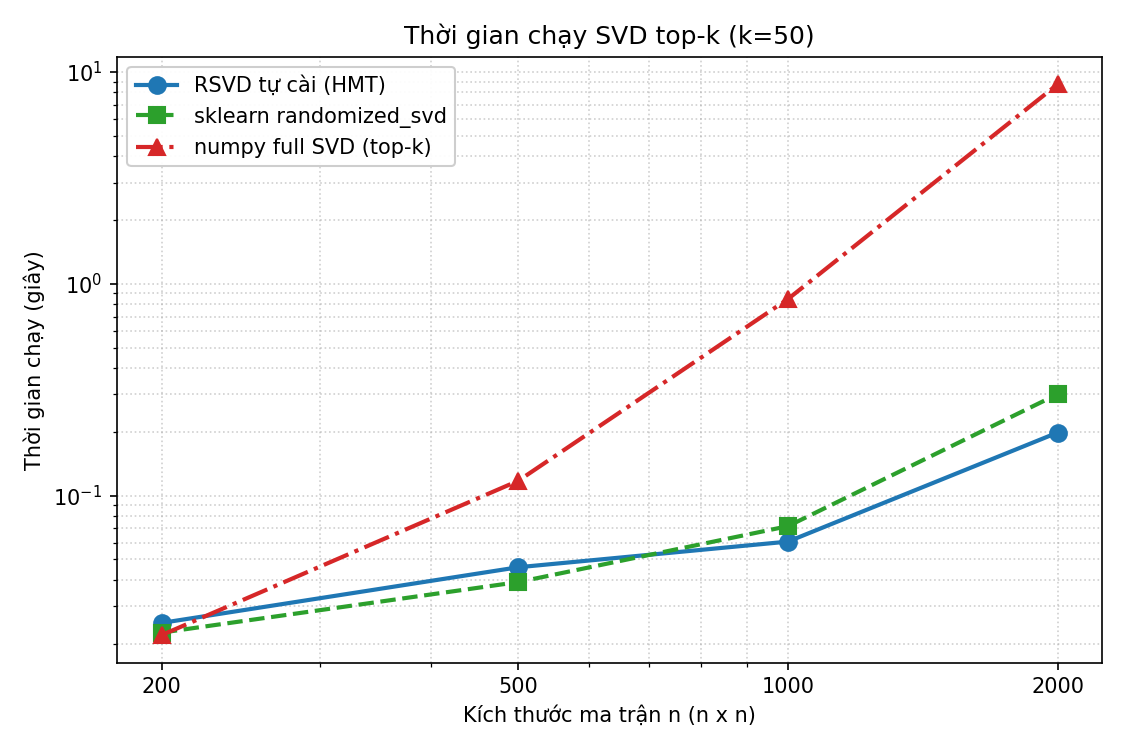

**Sai số Frobenius — RSVD vs full SVD**

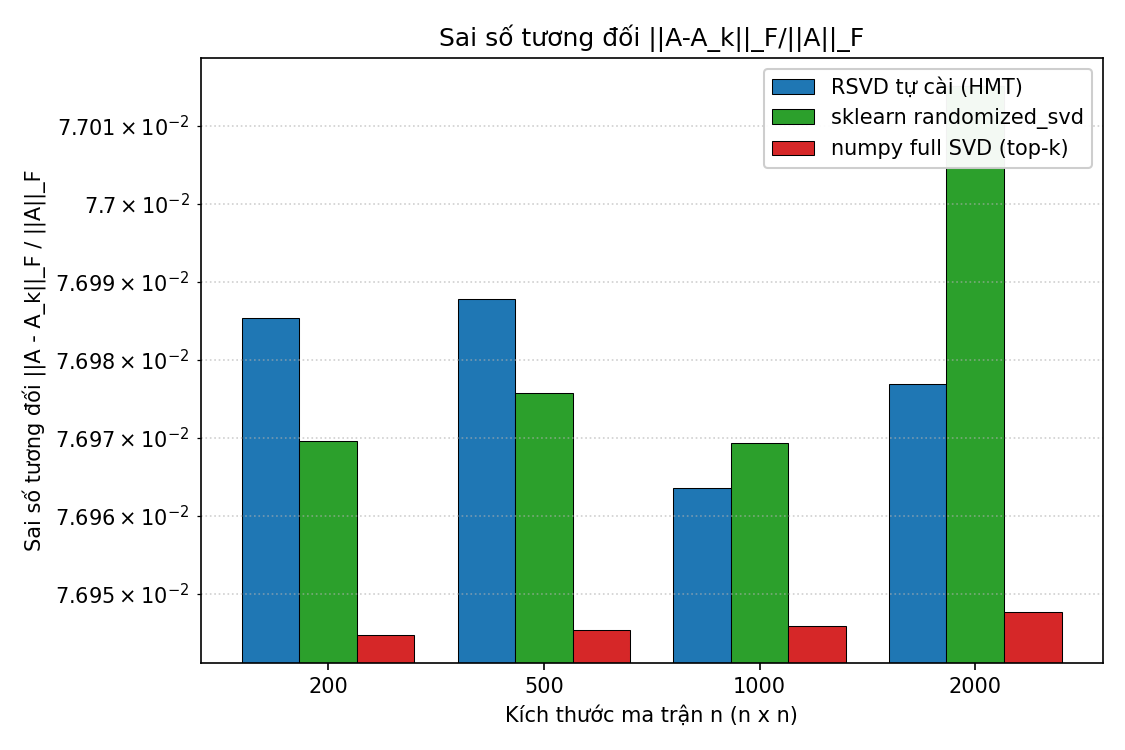

In [23]:
for fname, caption in [
    ("benchmark_runtime.png",  "Thời gian chạy theo kích thước ma trận"),
    ("benchmark_accuracy.png", "Sai số Frobenius — RSVD vs full SVD"),
]:
    path = f"report/images/results/{fname}"
    if os.path.exists(path):
        display(Markdown(f"**{caption}**"))
        display(Image(path))

In [24]:
with open("results/benchmark.json") as fh:
    bm = json.load(fh)

sizes   = sorted({r["size"] for r in bm["results"]})
methods = ["custom_rsvd", "sklearn_rsvd", "numpy_full_svd"]
header  = "   n   |" + "  ".join(f"{m:>16}" for m in methods)
print(header)
print("-" * len(header))
for n_val in sizes:
    cells = [f"{n_val:>5}  |"]
    for m in methods:
        hit = next((r for r in bm["results"] if r["size"] == n_val and r["method"] == m), None)
        if hit and hit.get("time_sec") is not None and not hit.get("timed_out"):
            cells.append(f"{hit['time_sec']:>15.3f}s")
        else:
            cells.append(f"{'(timeout)':>16}")
    print("  ".join(cells))

   n   |     custom_rsvd      sklearn_rsvd    numpy_full_svd
------------------------------------------------------------
  200  |            0.025s            0.023s            0.022s
  500  |            0.046s            0.039s            0.117s
 1000  |            0.061s            0.072s            0.847s
 2000  |            0.198s            0.301s            8.745s


## 5. Kết luận

- **Cài đặt RSVD tự viết** (`src/rsvd.py`) đạt độ chính xác xấp xỉ với `numpy.linalg.svd` (lệch dưới ~1% ở rank-$k$ với dữ liệu Gaussian) ⇒ thuật toán Halko–Martinsson–Tropp được triển khai đúng.
- **Dữ liệu DÀY (ảnh):** Randomized SVD nén thật — $k=50$ giữ ~96% năng lượng với tỉ lệ nén $5\times$; $k=10$ cho tỉ lệ nén $25\times$ với rel-err $\sim 13\%$.
- **Dữ liệu THƯA (rating):** biểu diễn nén $(U_k,\Sigma_k,V_k)$ **lớn hơn** CSR gốc vì $k(m+n+1) > \mathrm{nnz}(A)$ với mọi $k$ đủ lớn để giữ năng lượng cao. Điều kiện break-even $k_{be} = \mathrm{nnz}/(m+n+1)$ chính là tiêu chí định lượng cho việc "SVD có nén được dữ liệu này không?".
- **Benchmark:** Custom RSVD và sklearn cùng độ phức tạp, nhanh hơn full SVD theo lũy thừa của $n$.

**Báo cáo chi tiết:** [`report/main.pdf`](report/main.pdf) trong repo.